In [1]:
import sys
import os
import json
import torch
import torch.nn as nn
import math
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader
import warnings

warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath('../../..'))

In [2]:
from DL.models.rotate_net import RotateNet
from DL.models.cascade_net import CascadeNet
from DL.trainers.model_trainer import ModelTrainer
from DL.losses.rotation_loss import angular_cosine_loss
from DL.visualization.plot_utils import plot_confusion_matrices
from DL.visualization.classic_gradcam import visualize_classic_gradcam

# Импортируем оба ваших генератора
from mnist_synthetic.lower_case_letters_generator import LowerCaseLettersGenerator
from mnist_synthetic.generator import NumbersGenerator


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")

Используемое устройство: cuda


In [4]:
class RotatedCombinedDataset(Dataset):
    """
    Универсальный датасет, использующий ваши процедурные генераторы для букв и цифр.
    Вращает изображения на лету и подготавливает таргеты для RotateNet.
    """
    def __init__(self, num_samples: int, seed: int, max_angle: int = 150):
        self.num_samples = num_samples
        self.max_angle = max_angle
        self.rng = torch.Generator().manual_seed(seed)

        self.cyrillic_gen = LowerCaseLettersGenerator(seed=seed)
        self.digit_gen = NumbersGenerator(seed=seed)

        # Собираем все символы в единый словарь (33 буквы + 10 цифр = 43 класса)
        self.cyr_chars = self.cyrillic_gen.ALLOWS_SYMBOLS
        self.dig_chars =[str(i) for i in range(10)]

        self.char_to_idx = {char: idx for idx, char in enumerate(self.cyr_chars)}
        for idx, char in enumerate(self.dig_chars):
            self.char_to_idx[char] = idx + len(self.cyr_chars)

        self.idx_to_char = {v: k for k, v in self.char_to_idx.items()}

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        # Половина батча - буквы, половина - цифры
        if idx < self.num_samples // 2:
            img_np, label_char = self.cyrillic_gen.generate()
        else:
            img_np, label_char = self.digit_gen.generate()
            label_char = str(label_char) # Приводим цифру к строке для словаря

        img_tensor = torch.from_numpy(img_np).float().unsqueeze(0) / 255.0

        # Применяем случайное вращение
        angle = torch.empty(1).uniform_(-self.max_angle, self.max_angle, generator=self.rng).item()
        img_rotated = TF.rotate(img_tensor, angle)

        # Подготавливаем таргеты для RotateNet
        angle_rad = math.radians(angle)
        sin_cos_target = torch.tensor([math.sin(angle_rad), math.cos(angle_rad)], dtype=torch.float32)

        return img_rotated, self.char_to_idx[label_char], sin_cos_target

In [5]:
# Создаем датасеты. Берем 86к на трейн (по 1к примеров на каждый из 43 классов)
train_dataset = RotatedCombinedDataset(86000, seed=42, max_angle=150)
test_dataset = RotatedCombinedDataset(21500, seed=999, max_angle=150)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

print(f"Датасеты готовы. Общее количество классов: {len(train_dataset.char_to_idx)}")

Датасеты готовы. Общее количество классов: 43


In [6]:
# Используем конфигурацию с 32 координатами (16 каналов)
config_path_rot = '../../../DL/configs/rotatenet/rotatenet_spatial_32.json'
with open(config_path_rot, 'r') as f:
    config_rot = json.load(f)

In [7]:
print("=== ЭТАП 1: Обучение RotateNet (32 Spatial Keypoints) ===")
rotatenet = RotateNet(config_rot).to(device)
opt_rot = torch.optim.Adam(rotatenet.parameters(), lr=1e-3)

epochs_rot = 20
for epoch in range(epochs_rot):
    rotatenet.train()
    running_loss = 0.0

    for batch in train_loader:
        images, _, targets = batch[0].to(device), batch[1].to(device), batch[2].to(device)

        opt_rot.zero_grad()
        pred_sin_cos, _ = rotatenet(images)
        loss = angular_cosine_loss(pred_sin_cos, targets, limit_deg=150.0)

        loss.backward()
        opt_rot.step()
        running_loss += loss.item() * images.size(0)

    avg_loss = running_loss / len(train_dataset)
    print(f"Эпоха {epoch+1}/{epochs_rot} | Angular Loss: {avg_loss:.4f}")

=== ЭТАП 1: Обучение RotateNet (32 Spatial Keypoints) ===
Эпоха 1/20 | Angular Loss: 0.6310
Эпоха 2/20 | Angular Loss: 0.4684
Эпоха 3/20 | Angular Loss: 0.3745
Эпоха 4/20 | Angular Loss: 0.3321
Эпоха 5/20 | Angular Loss: 0.2977
Эпоха 6/20 | Angular Loss: 0.2975
Эпоха 7/20 | Angular Loss: 0.2500
Эпоха 8/20 | Angular Loss: 0.2489
Эпоха 9/20 | Angular Loss: 0.3634
Эпоха 10/20 | Angular Loss: 0.3651
Эпоха 11/20 | Angular Loss: 0.2387
Эпоха 12/20 | Angular Loss: 0.2151
Эпоха 13/20 | Angular Loss: 0.2114
Эпоха 14/20 | Angular Loss: 0.1985
Эпоха 15/20 | Angular Loss: 0.1951
Эпоха 16/20 | Angular Loss: 0.2192
Эпоха 17/20 | Angular Loss: 0.2173
Эпоха 18/20 | Angular Loss: 0.2570
Эпоха 19/20 | Angular Loss: 0.1829
Эпоха 20/20 | Angular Loss: 0.1749


In [8]:
# Загружаем LeNet 8KB и устанавливаем 43 класса
config_path_lenet = '../../../DL/configs/lenet/lenet_8kb.json'
with open(config_path_lenet, 'r') as f:
    config_lenet = json.load(f)
config_lenet['num_classes'] = len(train_dataset.char_to_idx)

In [9]:
print("\n=== ЭТАП 2: Обучение CascadeNet (Polar Fusion + Dynamic Curriculum) ===")
# stn_iters=2 включает итеративное выравнивание, use_polar=True включает инвариантные радиусы
cascade_model = CascadeNet(config_lenet, rotatenet, use_polar=True, stn_iters=2).to(device)

# Размораживаем RotateNet для End-to-End дообучения
for param in cascade_model.rotatenet.parameters():
    param.requires_grad = True

# RotateNet учим медленнее, чтобы не сломать выученные центры масс
optimizer_cascade = torch.optim.Adam([
    {'params': cascade_model.classifier.parameters(), 'lr': 1e-3},
    {'params': cascade_model.rotatenet.parameters(), 'lr': 5e-5}
])

trainer_cascade = ModelTrainer(
    model=cascade_model,
    optimizer=optimizer_cascade,
    criterion=nn.CrossEntropyLoss(),
    device=device,
    use_background_loss=True,
    bg_loss_alpha=10.0, # Стартовое значение, будет уменьшаться
    bg_loss_n=2
)

epochs_cascade = 30
for epoch in range(1, epochs_cascade + 1):
    # Плавное усложнение углов: 30°, 60°, 90°, 120°, 150° (шаг каждые 3 эпохи)
    if epoch <= 12:
        current_max_angle = 30 + ((epoch - 1) // 3) * 30
    else:
        current_max_angle = 150

    # Динамическое затухание Background Loss (от 10.0 до 2.0)
    # На сложных углах интерполяция размывает края, поэтому мы снижаем штраф за фон
    current_bg_alpha = 10.0 - (current_max_angle / 150.0) * 8.0

    # Обновляем параметры среды на лету
    train_dataset.max_angle = current_max_angle
    trainer_cascade.bg_loss_alpha = current_bg_alpha

    print(f"Эпоха {epoch}/{epochs_cascade} | Угол: ±{current_max_angle}° | Alpha BG: {current_bg_alpha:.1f}")

    train_metrics = trainer_cascade.train_epoch(train_loader)
    val_metrics = trainer_cascade.evaluate(test_loader) # Тест всегда на 150 градусах!

    print(f"Трейн Лосс: {train_metrics['loss']:.4f} | Точность: {train_metrics['acc']:.4f}")
    print(f"Валид Лосс: {val_metrics['loss']:.4f} | Точность: {val_metrics['acc']:.4f}\n")


=== ЭТАП 2: Обучение CascadeNet (Polar Fusion + Dynamic Curriculum) ===
Эпоха 1/30 | Угол: ±30° | Alpha BG: 8.4


Трейн Лосс: 2.1028 | Точность: 0.4851
Валид Лосс: 3.2375 | Точность: 0.3304

Эпоха 2/30 | Угол: ±30° | Alpha BG: 8.4


Трейн Лосс: 0.3732 | Точность: 0.9177
Валид Лосс: 4.1654 | Точность: 0.4035

Эпоха 3/30 | Угол: ±30° | Alpha BG: 8.4


Трейн Лосс: 0.1005 | Точность: 0.9784
Валид Лосс: 5.1397 | Точность: 0.4283

Эпоха 4/30 | Угол: ±60° | Alpha BG: 6.8


Трейн Лосс: 0.2852 | Точность: 0.9275
Валид Лосс: 3.7632 | Точность: 0.5631

Эпоха 5/30 | Угол: ±60° | Alpha BG: 6.8


...

Трейн Лосс: 0.1884 | Точность: 0.9484
Валид Лосс: 0.1845 | Точность: 0.9488

Эпоха 27/30 | Угол: ±150° | Alpha BG: 2.0


Трейн Лосс: 0.1790 | Точность: 0.9512
Валид Лосс: 0.1716 | Точность: 0.9521

Эпоха 28/30 | Угол: ±150° | Alpha BG: 2.0


Трейн Лосс: 0.1812 | Точность: 0.9500
Валид Лосс: 0.1709 | Точность: 0.9540

Эпоха 29/30 | Угол: ±150° | Alpha BG: 2.0


Трейн Лосс: 0.1726 | Точность: 0.9523
Валид Лосс: 0.1669 | Точность: 0.9543

Эпоха 30/30 | Угол: ±150° | Alpha BG: 2.0


Трейн Лосс: 0.1639 | Точность: 0.9536
Валид Лосс: 0.1579 | Точность: 0.9565




Матрица ошибок (43 класса):


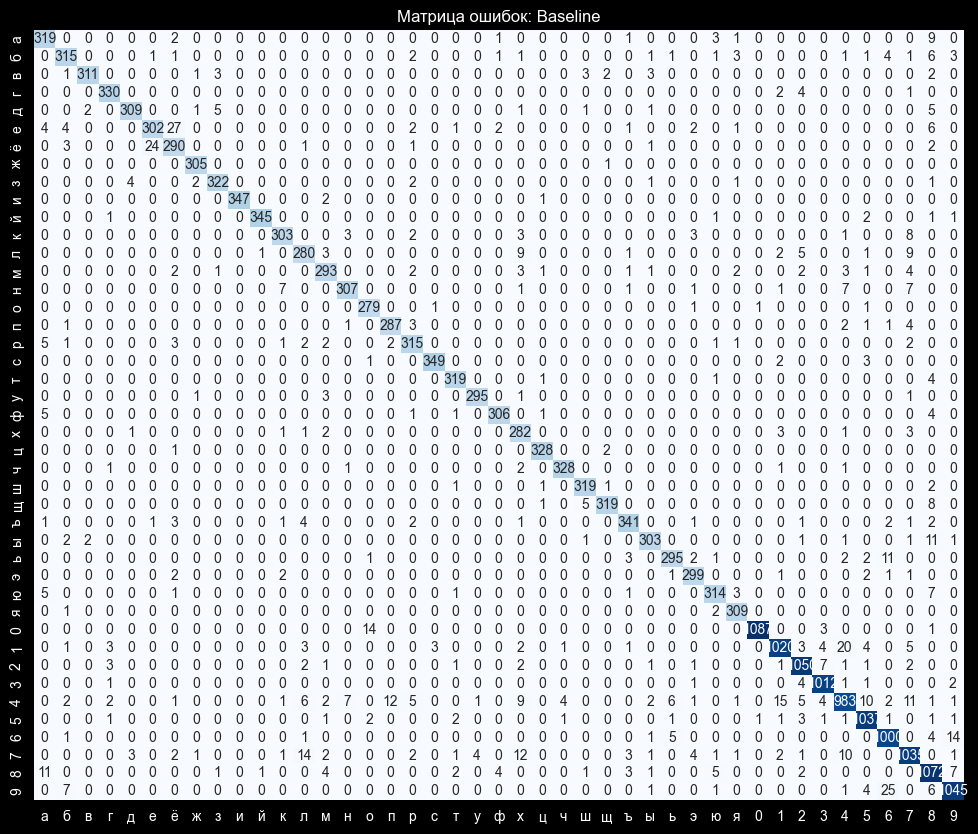

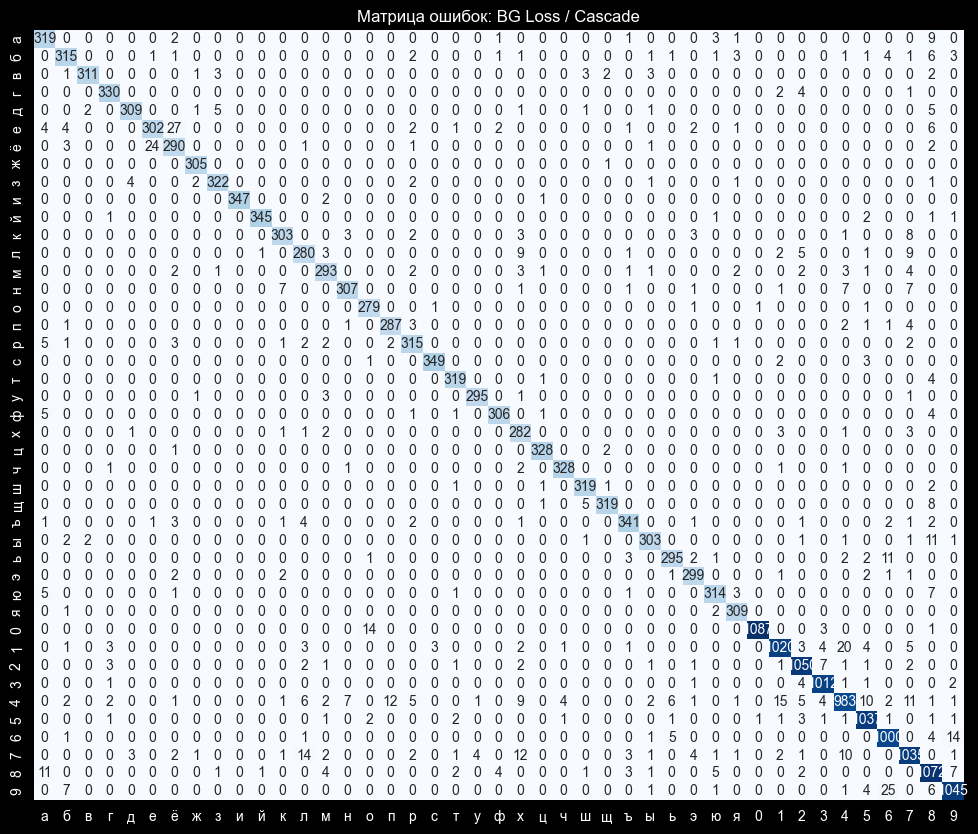

In [10]:
# Визуализация и оценка
print("\nМатрица ошибок (43 класса):")
plot_confusion_matrices(cascade_model, cascade_model, test_loader, test_dataset, device)


Визуализация признаков через Classic Grad-CAM:


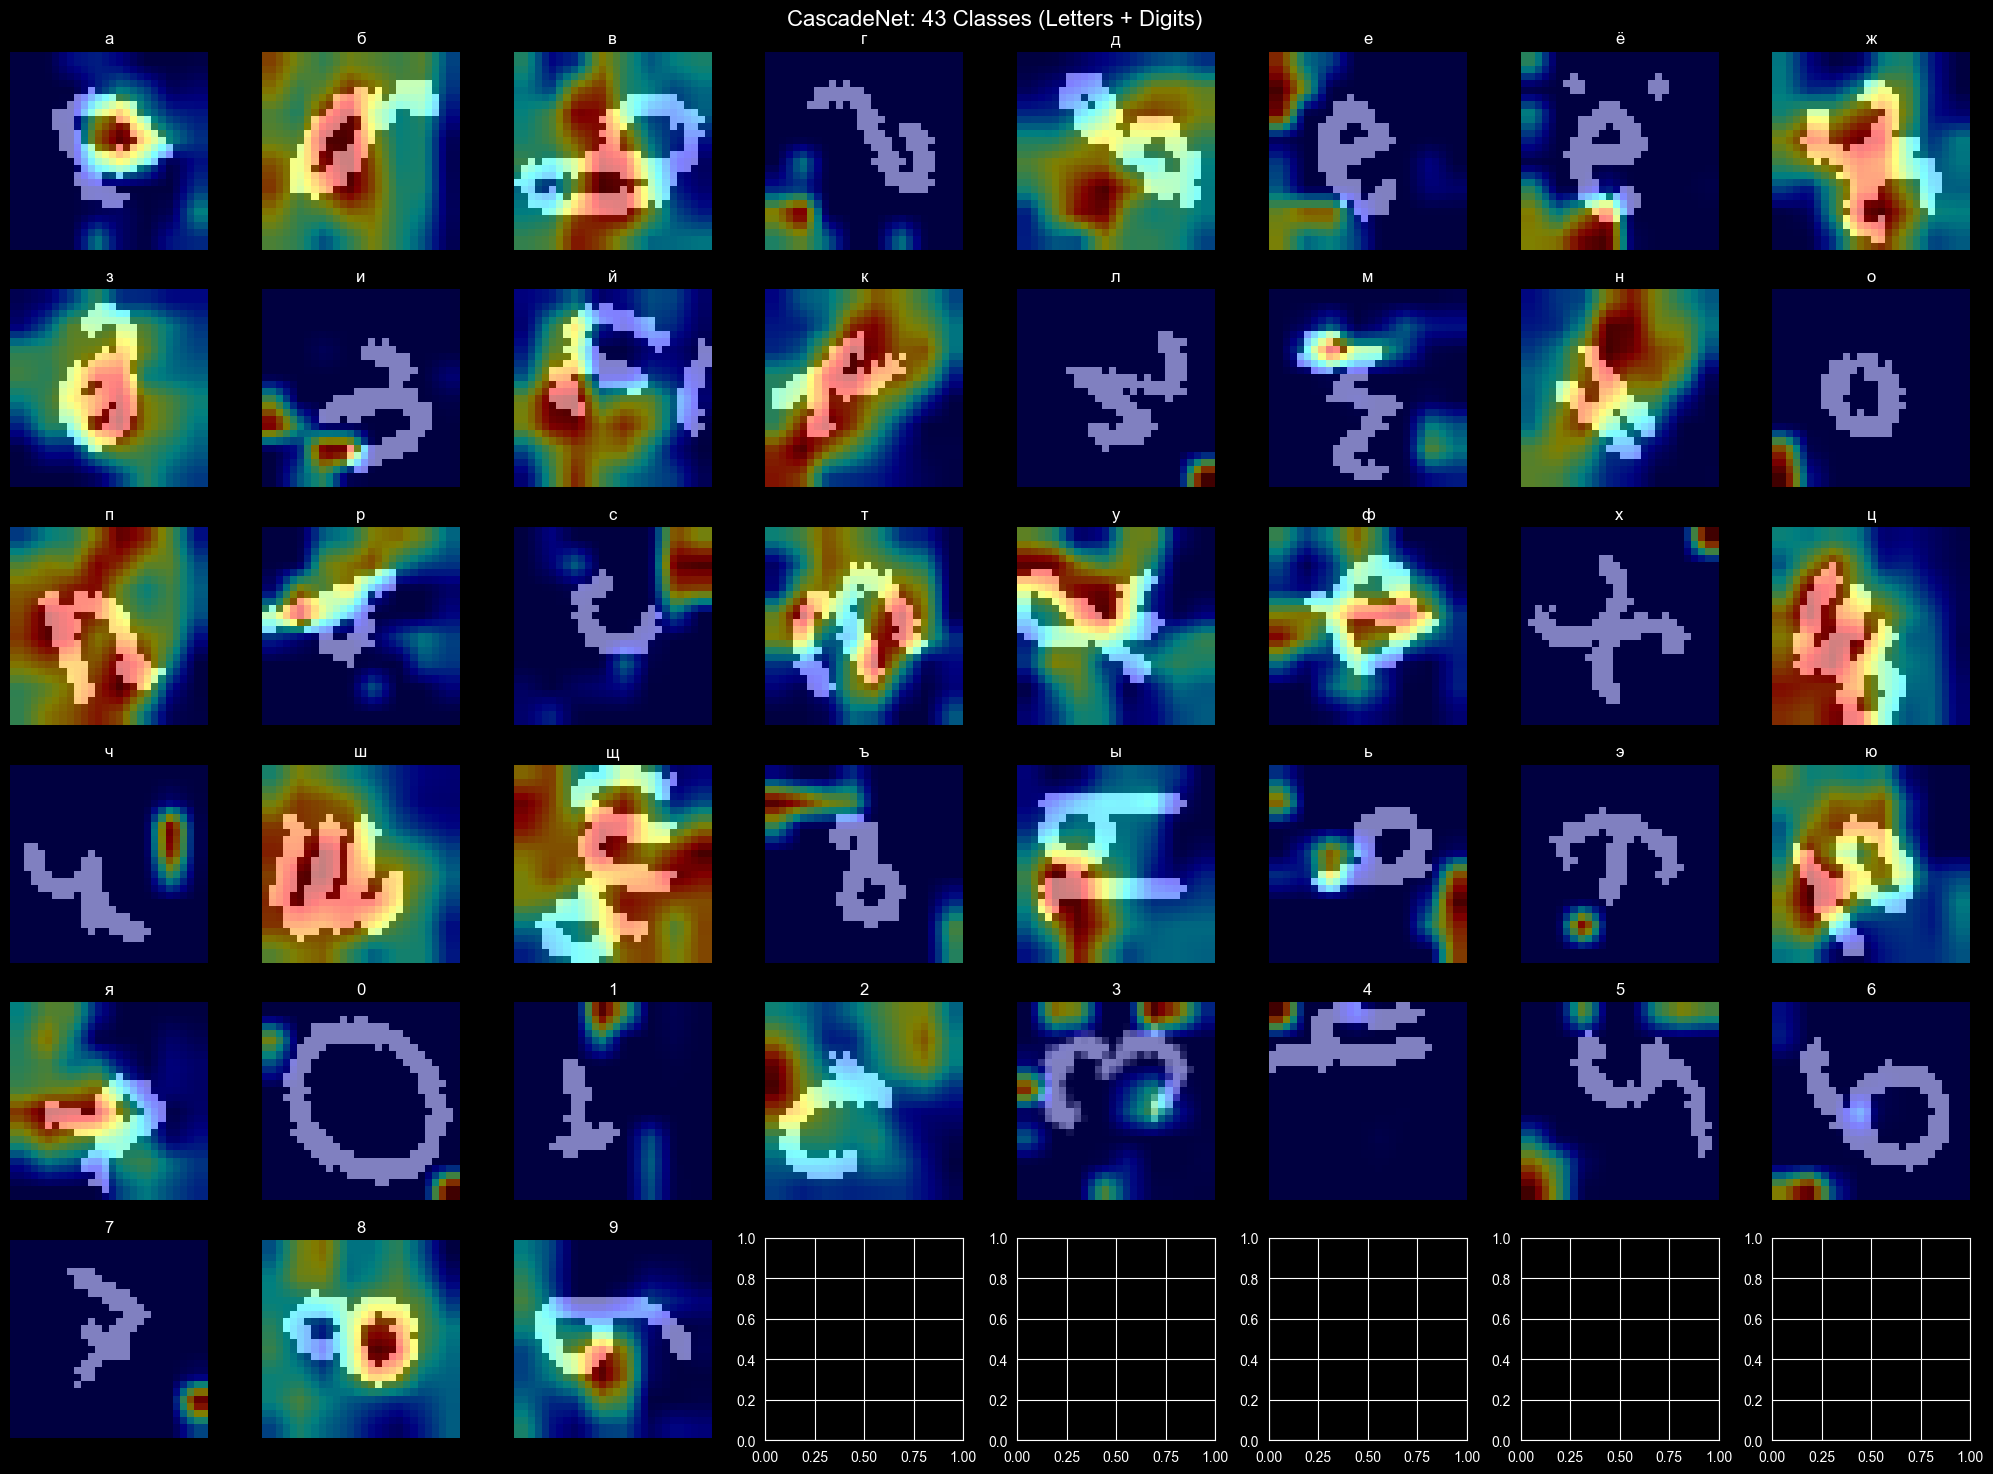

In [11]:
print("\nВизуализация признаков через Classic Grad-CAM:")
visualize_classic_gradcam(cascade_model, test_dataset, device, "CascadeNet: 43 Classes (Letters + Digits)")

In [12]:
import torchvision.datasets as datasets
import torchvision.transforms.functional as TF
import math
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from DL.trainers.model_trainer import ModelTrainer

print("=== ЭКСПЕРИМЕНТ: Transfer Learning на классический MNIST ===")

class StandardMNISTRotated(Dataset):
    """
    Обертка для классического датасета MNIST.
    Вращает изображения и сдвигает метки классов, чтобы они
    совпадали с нашей архитектурой (где цифрам отведены индексы 33-42).
    """
    def __init__(self, is_train: bool, max_angle: int = 150):
        # Загружаем классический MNIST. Он скачается в папку ./data, если его нет.
        self.mnist = datasets.MNIST(root='./data', train=is_train, download=True)
        self.max_angle = max_angle
        # Сдвиг меток (кириллица занимает индексы 0-32)
        self.label_offset = 33

    def __len__(self):
        return len(self.mnist)

    def __getitem__(self, idx):
        img_pil, label = self.mnist[idx]

        # Преобразуем PIL Image в Tensor[1, 28, 28] со значениями 0.0 - 1.0
        img_tensor = TF.to_tensor(img_pil)

        # Применяем случайное вращение
        angle = torch.empty(1).uniform_(-self.max_angle, self.max_angle).item()
        img_rotated = TF.rotate(img_tensor, angle)

        # Сдвигаем метку класса
        adjusted_label = label + self.label_offset

        # Возвращаем в формате (изображение, метка, заглушка для таргета RotateNet)
        # Заглушку передаем просто нулями, так как при дообучении мы используем
        # только сквозной градиент от CrossEntropy, а не угловой лосс.
        return img_rotated, adjusted_label, torch.zeros(2)

# 1. Подготовка датасетов классического MNIST
mnist_train = StandardMNISTRotated(is_train=True, max_angle=150)
mnist_test = StandardMNISTRotated(is_train=False, max_angle=150)

mnist_train_loader = DataLoader(mnist_train, batch_size=256, shuffle=True)
mnist_test_loader = DataLoader(mnist_test, batch_size=256, shuffle=False)

print(f"Размер оригинального MNIST: Train={len(mnist_train)}, Test={len(mnist_test)}")

# 2. Замер до дообучения (Zero-Shot Evaluation)
print("\nЗамер метрик ДО дообучения (Zero-Shot Transfer):")
# Используем уже созданный в ноутбуке trainer_cascade для оценки
zero_shot_metrics = trainer_cascade.evaluate(mnist_test_loader)
print(f"Точность на тестовом оригинальном MNIST (без дообучения): {zero_shot_metrics['acc']:.4f}")

# 3. Настройка параметров для дообучения (Fine-Tuning)
print("\nЗапуск дообучения на реальном MNIST (5 эпох)...")

# Снижаем learning rate, чтобы не разрушить выученные на синтетике веса
optimizer_finetune = torch.optim.Adam([
    {'params': cascade_model.classifier.parameters(), 'lr': 3e-4},
    {'params': cascade_model.rotatenet.parameters(), 'lr': 1e-5}
])

trainer_finetune = ModelTrainer(
    model=cascade_model,
    optimizer=optimizer_finetune,
    criterion=nn.CrossEntropyLoss(),
    device=device,
    use_background_loss=True,
    bg_loss_alpha=2.0, # Оставляем низкий штраф, так как углы 150 градусов
    bg_loss_n=2
)

# 4. Дообучение
history_finetune = trainer_finetune.fit(mnist_train_loader, mnist_test_loader, epochs=5)

# 5. Финальный замер
print("\n=== Итоги Transfer Learning ===")
print(f"Точность ДО дообучения:    {zero_shot_metrics['acc']:.4f}")
print(f"Точность ПОСЛЕ дообучения: {history_finetune['val_acc'][-1]:.4f}")

=== ЭКСПЕРИМЕНТ: Transfer Learning на классический MNIST ===


100%|██████████| 9.91M/9.91M [00:02<00:00, 4.64MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 183kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.57MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.55MB/s]


Размер оригинального MNIST: Train=60000, Test=10000

Замер метрик ДО дообучения (Zero-Shot Transfer):
Точность на тестовом оригинальном MNIST (без дообучения): 0.2692

Запуск дообучения на реальном MNIST (5 эпох)...
Эпоха 1/5


Трейн Лосс: 3.8348 | Точность: 0.4009 | BG Лосс: 0.0001
Валид Лосс: 2.1408 | Точность: 0.5019

Эпоха 2/5


Трейн Лосс: 1.7541 | Точность: 0.5501 | BG Лосс: 0.0000
Валид Лосс: 1.4798 | Точность: 0.5905

Эпоха 3/5


Трейн Лосс: 1.3297 | Точность: 0.6259 | BG Лосс: 0.0000
Валид Лосс: 1.1590 | Точность: 0.6609

Эпоха 4/5


Трейн Лосс: 1.1228 | Точность: 0.6706 | BG Лосс: 0.0000
Валид Лосс: 1.0029 | Точность: 0.6932

Эпоха 5/5


Трейн Лосс: 0.9835 | Точность: 0.7043 | BG Лосс: 0.0000
Валид Лосс: 0.9037 | Точность: 0.7189


=== Итоги Transfer Learning ===
Точность ДО дообучения:    0.2692
Точность ПОСЛЕ дообучения: 0.7189
